# Movie Reviews Sentiment Analysis Project

## Project Overview

This notebook implements a streamlined Natural Language Processing (NLP) pipeline for performing binary sentiment analysis on the IMDB dataset (50k Movie Reviews). The workflow relies exclusively on textual content to distinguish between positive and negative reviews. The approach emphasizes context-aware cleaning (handling negations and slang), advanced TF-IDF vectorization with N-grams to capture local context, and training robust classifiers like Logistic Regression, Complement Naive Bayes, and XGBoost.

## Objectives

1. **Data Ingestion & Cleaning:** Load raw IMDB data and perform essential cleaning such as HTML tag removal, URL stripping, and duplicate removal.
2. **Context-Aware Preprocessing:** Implement specialized text processing, including slang expansion and "negation-preserving" stopword removal to maintain critical sentiment signals (e.g., keeping "not" and "no").
3. **Advanced Vectorization:** Transform text data into numerical vectors using TF-IDF with a wide N-gram range (Unigrams, Bigrams, and Trigrams) to capture semantic relationships between words.
4. **Model Training & Ensemble:** Train and evaluate multiple supervised learning models (Logistic Regression, Complement Naive Bayes, XGBoost) and explore Voting Classifiers.
5. **Hyperparameter Optimization:** Apply RandomizedSearchCV and GridSearchCV to fine-tune model parameters (C-values, Alpha, Tree depth) for maximum accuracy.

In [1]:
# ==========================================
# Importing Required Libraries
# ==========================================
import numpy as np
import pandas as pd
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import loguniform, randint,uniform
import nltk
import textstat
import contractions
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV,train_test_split,cross_val_score,StratifiedKFold,learning_curve
from sklearn.feature_selection import SelectKBest, chi2
import scipy.sparse as sp
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer,StandardScaler,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
import optuna
from optuna.integration import OptunaSearchCV
import joblib

## NLTK Resources Download

This section downloads and initializes all required NLTK components for text processing:
- **Tokenizers**: For sentence and word segmentation
- **POS Taggers**: For part-of-speech tagging used in lemmatization
- **Corpora**: WordNet for lemmatization and stopwords for noise removal


In [2]:
# Download required NLTK data packages for text preprocessing
nltk.download('punkt')                         # Sentence and word tokenizer
nltk.download('stopwords')                     # English stopwords corpus
nltk.download('wordnet')                       # Lexical database for lemmatization
nltk.download('omw-1.4')                       # Open Multilingual Wordnet
nltk.download('averaged_perceptron_tagger')    # POS tagger model
nltk.download('averaged_perceptron_tagger_eng') # English-specific POS tagger
nltk.download('punkt_tab')                     # Updated tokenizer resources

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\aa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is

True

## SECTION 1: Data Loading and Initial Setup

### Purpose
Initialize the analysis environment by loading the IMDB dataset, verifying data quality, and formatting the target variable for binary classification tasks.

### Operations Performed

1. **Data Loading**: Import the IMDB Movie Reviews dataset (50,000 records) into a pandas DataFrame.
2. **Integrity Check**: Verify that the dataset contains no missing values or duplicate entries to ensure a clean starting corpus.
3. **Label Encoding**: Convert the categorical `sentiment` column into a binary format (Positive = 1, Negative = 0) for supervised learning algorithms.

In [3]:
# Load the fake reviews dataset from local CSV file
file_path = r"D:\graduation project 1\IMDB Dataset.csv"
reviews = pd.read_csv(file_path)

In [4]:
# Display initial dataset structure and quality metrics
print(f"📌 Initial dataset shape: {reviews.shape}")
print(f"📌 Columns: {reviews.columns.tolist()}")
print(f"📌 Missing values:\n{reviews.isnull().sum()}")
reviews.head()

📌 Initial dataset shape: (50000, 2)
📌 Columns: ['review', 'sentiment']
📌 Missing values:
review       0
sentiment    0
dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Remove duplicates
reviews = reviews.drop_duplicates(subset="review", keep="first")

In [6]:
print(f"🔍 Rows before deduplication: {len(reviews) + reviews.duplicated(subset='review').sum()}")
print(f"🔍 Rows after deduplication: {len(reviews)}")
print(f"🔍 Duplicates removed: {reviews.duplicated(subset='review').sum()}")

🔍 Rows before deduplication: 49582
🔍 Rows after deduplication: 49582
🔍 Duplicates removed: 0


In [7]:
reviews['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [8]:
# Create binary target variable
reviews["target"] = np.where(reviews["sentiment"] == "positive", 1, 0)
reviews.drop(columns=["sentiment"], inplace=True)

In [9]:
# Check class distribution
print(f"📊 Target Distribution:")
print(reviews["target"].value_counts())
print(f"\n📊 Target Proportions:")
print(reviews["target"].value_counts(normalize=True))

📊 Target Distribution:
target
1    24884
0    24698
Name: count, dtype: int64

📊 Target Proportions:
target
1    0.501876
0    0.498124
Name: proportion, dtype: float64


## 🧹 SECTION 2: Text Preprocessing Pipeline

We apply a rigorous cleaning and normalization pipeline to the `review` column. This process transforms raw, unstructured text into a clean, standardized format while preserving critical sentiment signals.

The pipeline executes the following specific steps:

### Key Processes:

1.  **Noise Removal & Standardization:**
    * **Cleaning:** Removes artifacts like HTML tags, URLs, and email addresses using regular expressions.
    * **Normalization:** Expands English contractions (e.g., "don't" → "do not") using the `contractions` library.
    * **Filtering:** Converts text to **lowercase** and removes all **non-alphabetic characters** (punctuation and numbers).
    * **Slang Expansion:** Maps common internet slang and abbreviations to their full forms (e.g., "idk" → "i do not know", "gr8" → "great") using a custom dictionary.

2.  **Context-Aware Stopword Removal:**
    * Filters out common high-frequency words (e.g., "the", "is") to reduce feature space.
    * **Crucial Step:** Explicitly **excludes negation words** (e.g., "not", "no", "never", "didn't") from the stopword list. This ensures that negative sentiment is preserved and not removed during cleaning.

3.  **POS-Based Lemmatization:**
    * **Tokenization & Tagging:** Splits text into tokens and applies **Part-of-Speech (POS) tagging** to identify whether each word is a Noun, Verb, Adjective, or Adverb.
    * **Lemmatization:** Uses the **WordNetLemmatizer** with the specific POS tag to accurately reduce words to their dictionary root (e.g., identifying "better" as an adjective and converting it to "good", rather than just chopping the suffix).

In [10]:
# Slang / Abbreviation Expansion
slang_dict = {
    "urself": "yourself",
    "rly": "really",
    "rlly": "really",
    "srsly": "seriously",
    "afaik": "as far as i know",
    "luv": "love",
    "gr8": "great",
    "gud": "good",
    "b4": "before",
    "yea": "yeah",
    "ya": "you",
    "tho": "though",
    "btw": "by the way",
    "bcz": "because",
    "bc": "because",
    "cuz": "because",
    "coz": "because",
    "ima": "i am",
    "imma": "i am",
    "idk": "i do not know",
    "idc": "i do not care",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "thanx": "thanks",
    "u": "you",
    "ur": "your",
    "4u": "for you",
    "4me": "for me",
    "imo": "in my opinion",
    "imho": "in my honest opinion",
    "ppl": "people",
    "pkg": "package",
    "perf": "perfect",
    "rec": "recommend",
    "recd": "received",
    "def": "definitely",
    "prob": "problem",
    "info": "information",
    "cust": "customer",
    "qty": "quantity",
    "amz": "amazing",
    "amazin": "amazing",
    "fave": "favorite",
    "fav": "favorite",
    "awsm": "awesome",
    "fab": "fantastic",
    "lit": "excellent",
    "legit": "genuine",
    "omg": "oh my god",
    "dam": "damn",
    "meh": "not good",
    "ugh": "frustrating",
    "gah": "annoying",
    "didnt": "did not",
    "doesnt": "does not",
    "dont": "do not",
    "cant": "cannot",
    "couldnt": "could not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "wasnt": "was not",
    "werent": "were not",
    "isnt": "is not",
    "arent": "are not",
    "ive": "i have",
    "ill": "i will",
    "its": "it is",
    "aint": "is not",
    "wont": "will not",
    "btwn": "between",
    "thru": "through",
    "atm": "at the moment",
    "tbh": "to be honest",
    "rn": "right now",
    "ty": "thank you",
    "np": "no problem",
    "smh": "shaking my head",
    "asap": "as soon as possible"
}


def expand_slang(text):
    words = text.split()
    expanded = [slang_dict.get(w, w) for w in words]
    return " ".join(expanded)


In [11]:
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', text)
    # Expand contractions (using the logic from your function)
    text = contractions.fix(text)
    # lowercase
    text = text.lower()
    # remove punctuation & numbers, but leave spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Normalize multiple spaces 
    text = ' '.join(text.split())
    # Slang / Abbreviation Expansion
    text = expand_slang(text)
    return text

print("🧹 Cleaning text...")
reviews["review"] = reviews["review"].apply(clean_text)
print("✅ Text cleaning complete!")

🧹 Cleaning text...
✅ Text cleaning complete!


In [12]:
stop_words = set(stopwords.words("english"))
negation_words = {'no', 'not', 'nor', 'neither', 'none', 'never', "didn't", "wasn't", "don't"} 
stop_words = stop_words - negation_words

In [13]:
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

print("🔍 Removing stopwords...")
reviews["review"] = reviews["review"].apply(remove_stopwords)
print("✅ Stopwords removed!")

🔍 Removing stopwords...
✅ Stopwords removed!


In [14]:
# Show example of cleaned text
print("📝 Example of cleaned text:")
print(f"Original length: {len(reviews['review'].iloc[0])}")
print(reviews["review"].iloc[0][:200])

📝 Example of cleaned text:
Original length: 1133
one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust not show faint hearted timid show pulls no


In [15]:
lemmatizer = WordNetLemmatizer()

# Map POS tags to WordNet
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    return " ".join([lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags])

print("🔄 Lemmatizing text (this may take a while)...")
reviews["review"] = reviews["review"].apply(lemmatize_text)
print("✅ Lemmatization complete!")

🔄 Lemmatizing text (this may take a while)...
✅ Lemmatization complete!


## Section 6: Train-Test Split

To ensure an unbiased evaluation of the model's generalization capabilities, the dataset is partitioned into training and testing subsets.

**Methodology:**
* **Stratified Splitting:** We utilize the `stratify=y` parameter to preserve the original class distribution (Fake vs. Real reviews) in both subsets. This is crucial for avoiding sampling bias.
* **Data Isolation:** Splitting occurs *before* any vectorization or scaling to prevent **data leakage**, ensuring the model is trained strictly on the training set statistics.

In [16]:
X = reviews["review"]  
y = reviews["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Section 7: Evaluation Utilities for Pipelines

This section defines reusable helper functions to evaluate end-to-end scikit-learn pipelines on different datasets. The functions call the pipeline’s `predict` method internally and compute standard classification metrics without requiring manual prediction code in each experiment.

The utilities are intended for pipelines that combine preprocessing steps (such as TF-IDF vectorization and feature scaling) with a final classifier, rather than for single models used in isolation. They also provide visual diagnostics through confusion matrices and learning curves to help analyze overfitting and underfitting behaviour.

### 7.1 Comprehensive pipeline evaluation

The `evaluate_model` function provides a detailed report for a fitted pipeline on a given dataset (train or test). It prints accuracy, precision, recall, F1-score, a full classification report, and a confusion matrix, making it easy to compare different pipelines consistently.


In [ ]:
def evaluate_model(model, X, y, dataset_name="Dataset"):
    """
    Comprehensive model evaluation including key metrics and confusion matrix.
    
    Parameters:
    - model: trained model or pipeline
    - X: feature matrix
    - y: true target labels
    - dataset_name: name for display (e.g., 'Train', 'Test')
    """
    
    # Section header
    print(f"\n{'='*60}")
    print(f"📊 {dataset_name} Set Evaluation")
    print(f"{'='*60}")
    
    # 1) Make predictions
    y_pred = model.predict(X)
    
    # 2) Compute standard evaluation metrics
    acc = accuracy_score(y, y_pred)        # Overall correctness
    prec = precision_score(y, y_pred)      # How many predicted positives are correct
    rec = recall_score(y, y_pred)          # How many actual positives are correctly predicted
    f1 = f1_score(y, y_pred)               # Harmonic mean of precision and recall
    
    print(f"\n📈 Metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    # 3) Display detailed classification report
    print(f"\n📋 Classification Report:")
    print(classification_report(y, y_pred, target_names=['Positive', 'Negative']))
    
    # 4) Confusion matrix visualization
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Negative'],
                yticklabels=['Positive', 'Negative'])
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # 5) Print breakdown of confusion matrix
    print(f"\n🔢 Confusion Matrix Breakdown:")
    print(f"  True Negatives:  {cm[0, 0]}")
    print(f"  False Positives: {cm[0, 1]}")
    print(f"  False Negatives: {cm[1, 0]}")
    print(f"  True Positives:  {cm[1, 1]}")
    
# Confirmation message
print("✅ Evaluation function created!")


✅ Evaluation function created!


### 7.2 Learning curve analysis for pipelines

The `plot_learning_curve` function generates learning curves for a given pipeline using cross-validation. It visualizes how training and validation accuracy evolve as the training set size increases, and prints a brief diagnosis indicating whether the model is likely overfitting, underfitting, or reasonably well-balanced.

In [18]:
def plot_learning_curve(estimator, X, y, cv=5, n_jobs=-1):
    """
    Plot learning curves to diagnose overfitting/underfitting.
    
    Parameters:
    - estimator: Model pipeline or estimator to evaluate
    - X: Feature matrix
    - y: Target vector
    - cv: Number of cross-validation folds
    - n_jobs: Number of parallel jobs for computation
    """
    
    print("📈 Generating learning curves...")
    
    # Compute learning curves: train and cross-validation scores for increasing training sizes
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 5),  # Evaluate at 10%, 32.5%, 55%, 77.5%, 100% of training data
        scoring='accuracy',
    )
    
    # Compute mean and standard deviation for training and validation scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot learning curves
    plt.figure(figsize=(10, 6))
    
    # Training score curve
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='blue')  # Shaded area shows variance
    
    # Cross-validation score curve
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Cross-Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.1, color='red')
    
    # Plot styling
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title('Learning Curves')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate final scores and the gap between training and validation
    final_train_score = train_mean[-1]
    final_val_score = val_mean[-1]
    gap = final_train_score - final_val_score
    
    # Display learning curve diagnosis
    print(f"\n🔍 Learning Curve Diagnosis:")
    print(f"  Final Training Score:   {final_train_score:.4f}")
    print(f"  Final Validation Score: {final_val_score:.4f}")
    print(f"  Gap (Train - Val):      {gap:.4f}")
    
    # Analyze model bias/variance based on gap and score
    if gap > 0.05:
        print(f"  ⚠️ High variance detected (overfitting) - consider:")
        print(f"     • Regularization (e.g., lower C for SVM/Logistic Regression)")
        print(f"     • Reducing features (lower max_features for TF-IDF)")
        print(f"     • More training data")
    elif final_val_score < 0.75:
        print(f"  ⚠️ High bias detected (underfitting) - consider:")
        print(f"     • Adding features or higher-dimensional representations")
        print(f"     • Reducing regularization (higher C for SVM/Logistic Regression)")
        print(f"     • Using a more complex model")
    else:
        print(f"  ✅ Model appears well-balanced!")


###  We use `StratifiedKFold` to ensure that each fold maintains the same class distribution as the original dataset.  
This helps provide more reliable performance estimates

We apply it consistently in:
- Regular cross-validation for model evaluation.
- The cross-validation used inside `GridSearchCV` and `RandomizedSearchCV` for hyperparameter tuning.

In [19]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Section 9: Model Training

# 9.1 Logistic Regression

### Feature Extraction: TF-IDF Vectorizer
We define a base `TfidfVectorizer` to transform the preprocessed text into numerical vectors. We focus exclusively on textual content with the following configuration:

- **`ngram_range=(1, 2)`**: Captures single words (unigrams) and word pairs (bigrams) to understand local context (e.g., distinguishing "good" from "not good").
- **`max_df=0.6`**: Removes very common terms appearing in >60% of documents to filter out corpus-specific stopwords.
- **`min_df=0.0001`**: Filters out terms appearing in fewer than 0.01% of documents, ensuring that only statistically meaningful words contribute to the feature space.
- **`max_features=3000`**: Restricts the vocabulary to the top 3,000 most important features based on frequency.
- **`sublinear_tf=True`**: Applies logarithmic scaling to term frequency, reducing the dominance of extremely frequent words.
- **`norm='l2'`**: Normalizes vectors to unit length to ensure fair comparison between reviews of varying lengths.



In [20]:
tf_idf_base = TfidfVectorizer(
    lowercase=False,         # Already lowercased during preprocessing
    stop_words=None,         # Already removed stopwords
    ngram_range=(1, 2),      
    max_df=0.6,              
    min_df=0.0001,             
    max_features=3000,       
    sublinear_tf=True,      
    norm='l2',             
    smooth_idf=True )

## Train  Logistic Regression

Builds and trains a logistic regression classifier using the preprocessing pipeline:



###  Why use `clone(tf_idf_base)`?
We use `clone()` to create a **fresh, unfitted instance** of the preprocessor for each pipeline. This prevents **Data Leakage** by ensuring that shared statistics (like TF-IDF vocabulary) from one model do not contaminate the training process of another.


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9073
  Precision: 0.9008
  Recall:    0.9162
  F1-Score:  0.9084

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.91      0.90      0.91     19758
        Fake       0.90      0.92      0.91     19907

    accuracy                           0.91     39665
   macro avg       0.91      0.91      0.91     39665
weighted avg       0.91      0.91      0.91     39665



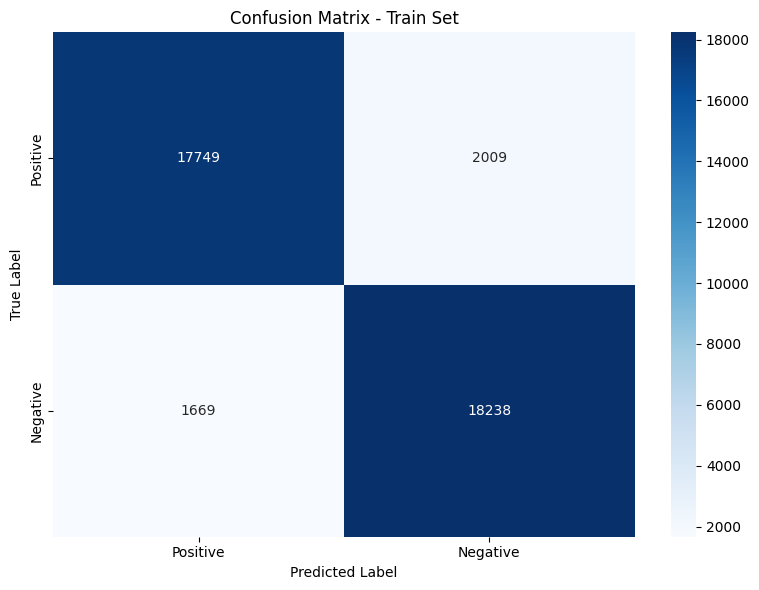


🔢 Confusion Matrix Breakdown:
  True Negatives:  17749
  False Positives: 2009
  False Negatives: 1669
  True Positives:  18238


In [21]:
# Create Logistic Regression pipeline
logistic_regression_pipeline = Pipeline([
    ("tfidf", clone(tf_idf_base)),
    ("clf", LogisticRegression())
])

# Fit pipeline on training data
logistic_regression_model = logistic_regression_pipeline.fit(X_train, y_train)

# Evaluate model on training data
# Prints accuracy, precision, recall, F1-score and shows confusion matrix
evaluate_model(logistic_regression_model, X_train, y_train, "Train")


## Cross-Validation Performance

Evaluates model generalization using **Stratified 3-Fold cross-validation**:  

- **skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)** ensures each fold preserves the class distribution.  
- Provides a robust and unbiased estimate of model performance on unseen data.


In [22]:
cv_scores = cross_val_score(
    logistic_regression_pipeline,
    X_train,
    y_train,
    cv=skf,                # StratifiedKFold object with 5 splits
    scoring="accuracy",    # 'scoring="accuracy"' evaluates model performance using accuracy
    n_jobs=-1              # 'n_jobs=-1' enables parallel computation on all available cores
)

# Display cross-validation scores for each fold
print("CV scores:", cv_scores)

# Calculate and display mean validation accuracy across all folds
print(f"Mean validation accuracy: {cv_scores.mean():.4f}")



CV scores: [0.88375435 0.88382998 0.88397247]
Mean validation accuracy: 0.8839


## Hyperparameter Tuning (GridSearchCV)

Searches for optimal hyperparameters using 3-fold stratified cross-validation

In [ ]:
# Parameter grid for Logistic Regression with TF-IDF
param_grid = {
    # TF-IDF settings 
    "tfidf__ngram_range": [(1, 2), (1, 3)],          # bigrams / trigrams
    "tfidf__max_df": [0.7, 0.8, 0.9],                # remove very frequent terms
    "tfidf__min_df": [0.0001, 0.0002, 0.0005],       # remove very rare terms
    "tfidf__max_features": [4000, 5000, 6000],       # vocabulary size

    # Logistic Regression 
    "clf__C": [0.6, 0.8, 1.1, 1.3],                  # regularization strength
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
}

# Grid search configuration
logistic_search = GridSearchCV(
    estimator=logistic_regression_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

print("Starting grid search for Logistic Regression...")
logistic_search.fit(X_train, y_train)

print(f"\nBest CV accuracy: {logistic_search.best_score_:.5f}")
print("Best parameters:", logistic_search.best_params_)

best_logistic_regression = logistic_search.best_estimator_


⏳ Starting Randomized Search 
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Best Validation Accuracy: 0.89232
🏆 Best Params: {'tfidf__ngram_range': (1, 3), 'tfidf__min_df': 0.0002, 'tfidf__max_features': 6000, 'tfidf__max_df': 0.7, 'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 1.3}



📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9216
  Precision: 0.9151
  Recall:    0.9301
  F1-Score:  0.9226

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.93      0.91      0.92     19758
        Fake       0.92      0.93      0.92     19907

    accuracy                           0.92     39665
   macro avg       0.92      0.92      0.92     39665
weighted avg       0.92      0.92      0.92     39665



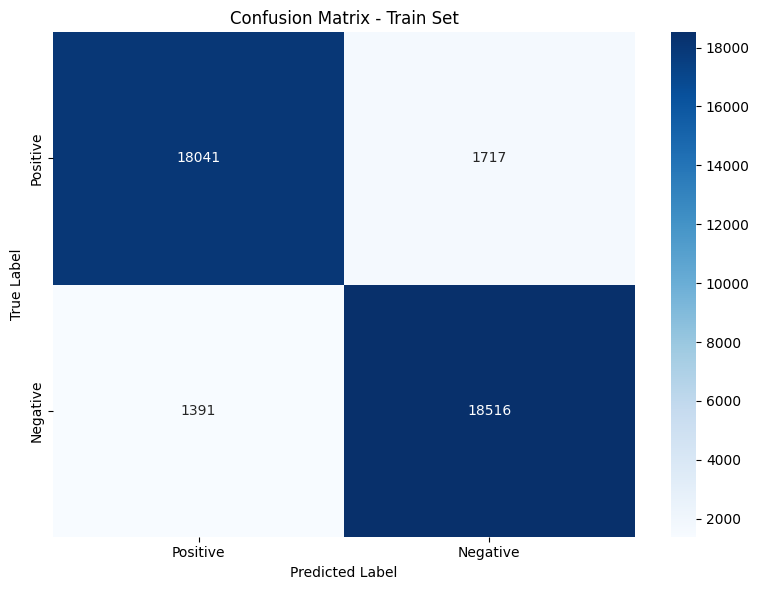


🔢 Confusion Matrix Breakdown:
  True Negatives:  18041
  False Positives: 1717
  False Negatives: 1391
  True Positives:  18516


In [ ]:
# Copy the best model obtained from RandomizedSearchCV
best_logistic_regression = logistic_search.best_estimator_

# Manually adjust selected pipeline hyperparameters
best_logistic_regression = best_logistic_regression.set_params(
    tfidf__ngram_range=(1, 3),
    tfidf__max_df=0.8,
    tfidf__min_df=0.0002,
    tfidf__max_features=5900,
    clf__C=1.1,
    clf__penalty="l2",
    clf__solver="liblinear"
)

# Retrain the model with the updated configuration
best_logistic_regression.fit(X_train, y_train)

# Re-evaluate performance on the training set
evaluate_model(best_logistic_regression, X_train, y_train, "Train")



##  Learning Curve - Tuned Model

Plots learning curve for the **best model** after hyperparameter tuning:

📈 Generating learning curves...


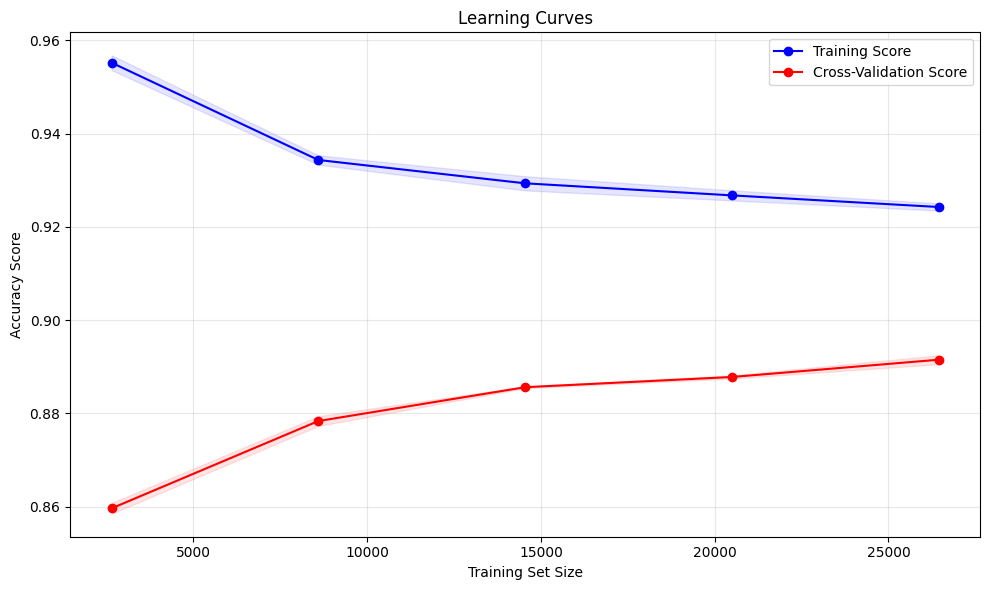


🔍 Learning Curve Diagnosis:
  Final Training Score:   0.9243
  Final Validation Score: 0.8915
  Gap (Train - Val):      0.0328
  ✅ Model appears well-balanced!


In [25]:
plot_learning_curve(
    best_logistic_regression , 
    X_train, 
    y_train, 
    cv=skf,
    n_jobs=-1
)

## Final Model Evaluation
Evaluates the best model (after hyperparameter tuning) on both train and test sets:


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9216
  Precision: 0.9151
  Recall:    0.9301
  F1-Score:  0.9226

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.93      0.91      0.92     19758
        Fake       0.92      0.93      0.92     19907

    accuracy                           0.92     39665
   macro avg       0.92      0.92      0.92     39665
weighted avg       0.92      0.92      0.92     39665



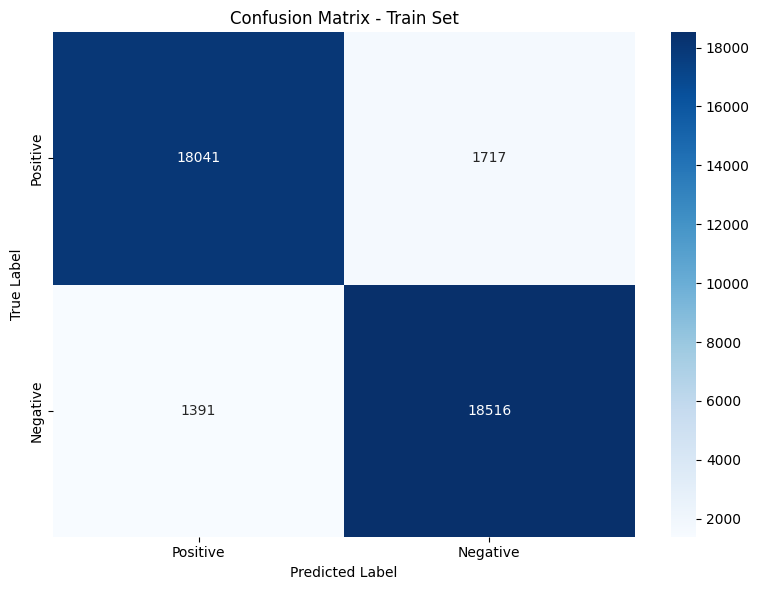


🔢 Confusion Matrix Breakdown:
  True Negatives:  18041
  False Positives: 1717
  False Negatives: 1391
  True Positives:  18516


In [26]:
# Evaluate on train set
evaluate_model( best_logistic_regression, X_train, y_train, "Train")


📊 Test Set Evaluation

📈 Metrics:
  Accuracy:  0.8960
  Precision: 0.8905
  Recall:    0.9040
  F1-Score:  0.8972

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.89      0.89      4940
        Fake       0.89      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



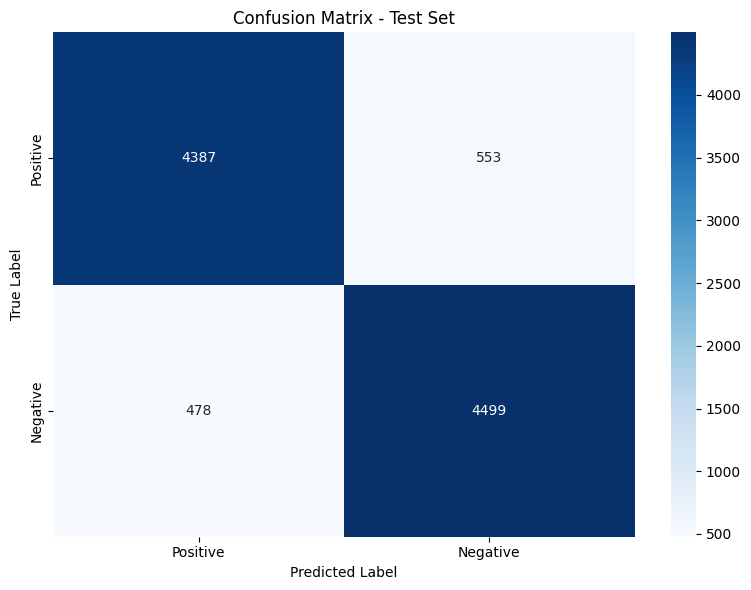


🔢 Confusion Matrix Breakdown:
  True Negatives:  4387
  False Positives: 553
  False Negatives: 478
  True Positives:  4499


In [27]:
# Evaluate on test set
evaluate_model( best_logistic_regression, X_test, y_test, "Test")

# 9.2 Naive Bayes

## Train  Naive Bayes

Builds and trains a SVM classifier using the preprocessing pipeline:


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.8615
  Precision: 0.8519
  Recall:    0.8763
  F1-Score:  0.8640

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.87      0.85      0.86     19758
        Fake       0.85      0.88      0.86     19907

    accuracy                           0.86     39665
   macro avg       0.86      0.86      0.86     39665
weighted avg       0.86      0.86      0.86     39665



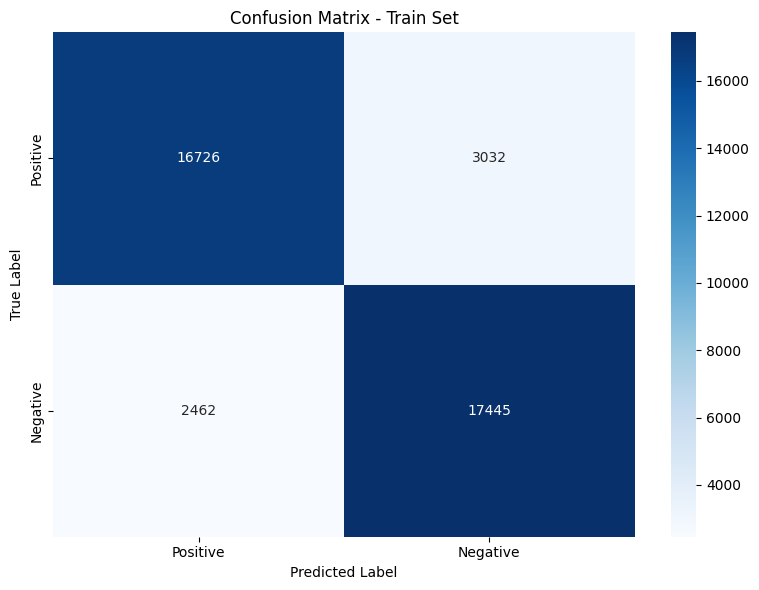


🔢 Confusion Matrix Breakdown:
  True Negatives:  16726
  False Positives: 3032
  False Negatives: 2462
  True Positives:  17445


In [29]:

from sklearn.naive_bayes import MultinomialNB, ComplementNB
cnb_pipeline = Pipeline([
    ("tfidf", clone(tf_idf_base)),
    ("clf", ComplementNB())
])
Naive_Bayes_model = cnb_pipeline.fit(X_train, y_train)
evaluate_model(Naive_Bayes_model, X_train, y_train, "Train")

## Cross-Validation Performance

Evaluates model generalization using **Stratified 5-Fold cross-validation**:  

- **skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)** ensures each fold preserves the class distribution.  
- Provides a robust and unbiased estimate of model performance on unseen data.

In [30]:
cv_scores = cross_val_score(
    Naive_Bayes_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)
print("CV scores:", cv_scores)
print(f"Mean validation accuracy: {cv_scores.mean():.4f}")


CV scores: [0.85425805 0.85630011 0.85568414]
Mean validation accuracy: 0.8554


## Hyperparameter Tuning (GridSearchCV)

Searches for optimal hyperparameters using 3-fold stratified cross-validation

In [ ]:
# 2. Expanded parameter grid for Complement Naive Bayes
param_grid_nb = {
    # TF-IDF settings 
    "tfidf__ngram_range": [(1, 2), (1, 3)],          # bigrams / trigrams
    "tfidf__max_features": [3000, 5000, 8000, 10000],
    "tfidf__max_df": [0.8],                         # remove very common terms
    "tfidf__min_df": [0.0001],                      # remove very rare terms

    # Complement Naive Bayes 
    "clf__alpha": [0.1, 0.5, 1.0, 1.5],              # smoothing strength
    "clf__norm": [True, False]                      # weight normalization
}

# 3. Grid search configuration
nb_search = GridSearchCV(
    cnb_pipeline,
    param_grid=param_grid_nb,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("Starting grid search for Complement Naive Bayes...")
nb_search.fit(X_train, y_train)

print(f"\nBest CV accuracy: {nb_search.best_score_:.5f}")
print("Best parameters:", nb_search.best_params_)

best_nb_model = nb_search.best_estimator_

🚀 Starting Expanded Grid Search for Complement Naive Bayes...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

✅ Best Validation Accuracy: 0.86840
🏆 Best Parameters: {'clf__alpha': 1.0, 'clf__norm': False, 'tfidf__max_df': 0.8, 'tfidf__max_features': 10000, 'tfidf__min_df': 0.0001, 'tfidf__ngram_range': (1, 3)}


##  Learning Curve - Tuned Model

Plots learning curve for the **best model** after hyperparameter tuning:

📈 Generating learning curves...


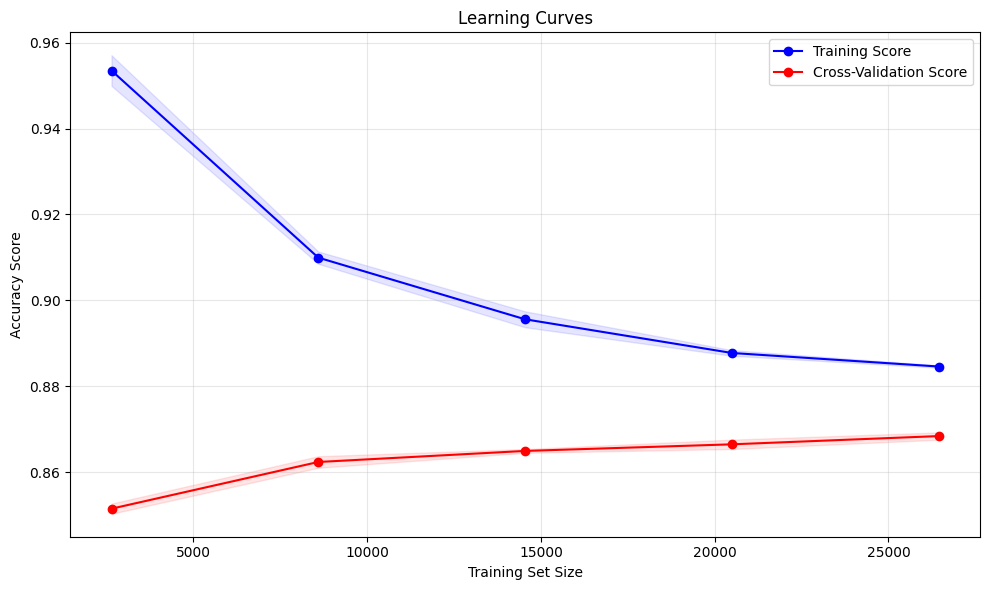


🔍 Learning Curve Diagnosis:
  Final Training Score:   0.8846
  Final Validation Score: 0.8684
  Gap (Train - Val):      0.0162
  ✅ Model appears well-balanced!


In [33]:
# make learning curve for best model
plot_learning_curve(
    best_nb_model, 
    X_train, 
    y_train, 
    cv=skf,
    n_jobs=-1
)

## Final Model Evaluation
Evaluates the best model (after hyperparameter tuning) on both train and test sets:


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.8798
  Precision: 0.8683
  Recall:    0.8966
  F1-Score:  0.8822

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.86      0.88     19758
        Fake       0.87      0.90      0.88     19907

    accuracy                           0.88     39665
   macro avg       0.88      0.88      0.88     39665
weighted avg       0.88      0.88      0.88     39665



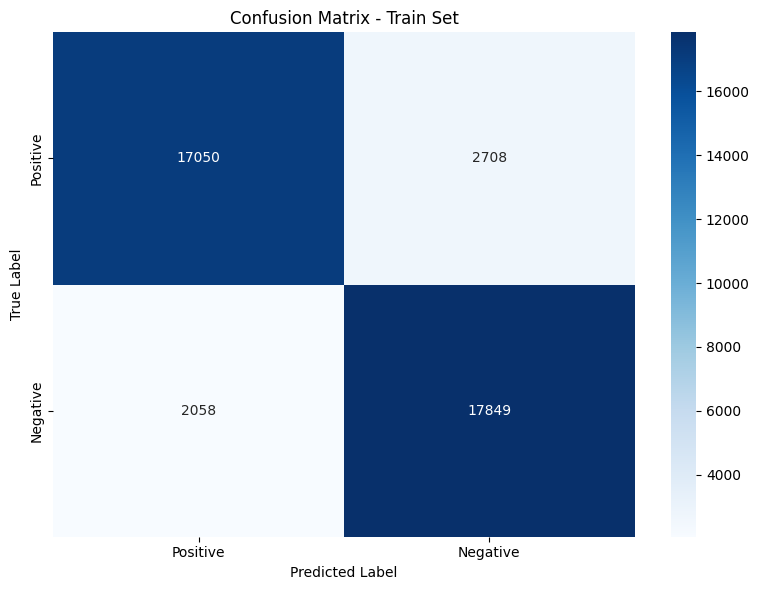


🔢 Confusion Matrix Breakdown:
  True Negatives:  17050
  False Positives: 2708
  False Negatives: 2058
  True Positives:  17849


In [34]:
# Evaluate on train set
evaluate_model( best_nb_model, X_train, y_train, "Train")


📊 Test Set Evaluation

📈 Metrics:
  Accuracy:  0.8695
  Precision: 0.8620
  Recall:    0.8811
  F1-Score:  0.8714

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.88      0.86      0.87      4940
        Fake       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



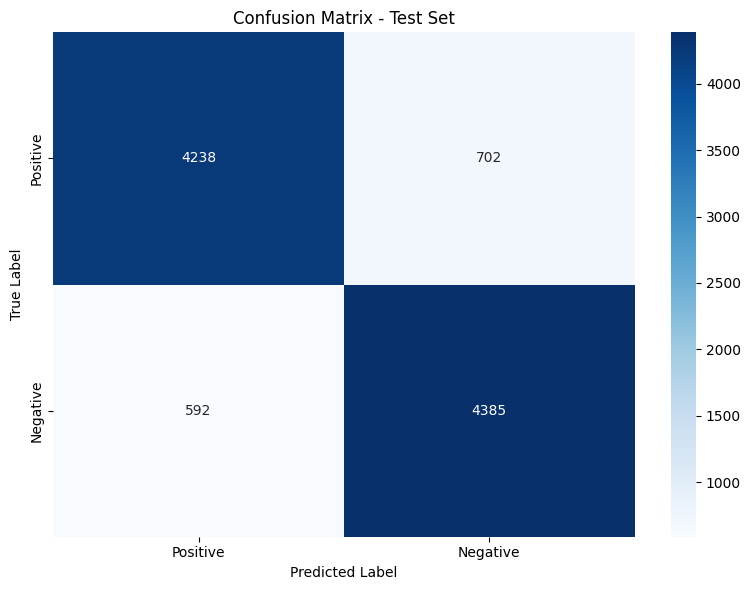


🔢 Confusion Matrix Breakdown:
  True Negatives:  4238
  False Positives: 702
  False Negatives: 592
  True Positives:  4385


In [35]:
# Evaluate on test set
evaluate_model( best_nb_model, X_test, y_test, "Test")

# 9.3 XGBOOST

## Train XGBOOST

Builds and trains a XGB classifier using the preprocessing pipeline:


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9339
  Precision: 0.9196
  Recall:    0.9515
  F1-Score:  0.9353

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.92      0.93     19758
        Fake       0.92      0.95      0.94     19907

    accuracy                           0.93     39665
   macro avg       0.93      0.93      0.93     39665
weighted avg       0.93      0.93      0.93     39665



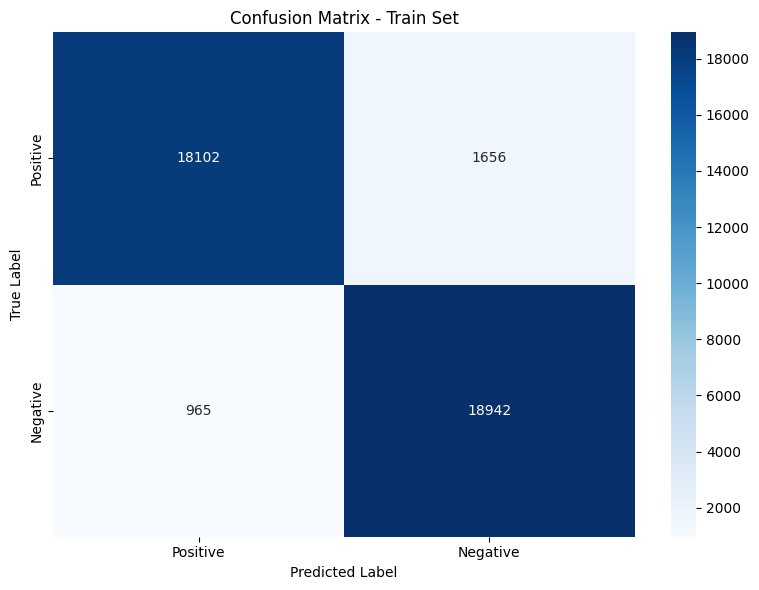


🔢 Confusion Matrix Breakdown:
  True Negatives:  18102
  False Positives: 1656
  False Negatives: 965
  True Positives:  18942


In [36]:
xgb_pipeline = Pipeline([
    ("tfidf", clone(tf_idf_base)),   # Clone the preprocessor to start fresh for this pipeline
     ("clf", XGBClassifier())
])
xgb_model = xgb_pipeline.fit(X_train, y_train)
evaluate_model(xgb_model, X_train, y_train, "Train")

## Cross-Validation Performance

Evaluates model generalization using **Stratified 3-Fold cross-validation**:  

- **skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)** ensures each fold preserves the class distribution.  
- Provides a robust and unbiased estimate of model performance on unseen data.

In [37]:
cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)
print("CV scores:", cv_scores)
print(f"Mean validation accuracy: {cv_scores.mean():.4f}")


CV scores: [0.85425805 0.85327484 0.85439831]
Mean validation accuracy: 0.8540


## Hyperparameter Tuning (RandomizedSearchCV)

Searches for optimal hyperparameters using 3-fold stratified cross-validation

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost val accuracy: 0.847951619836237
Best XGBoost params: {'clf__colsample_bylevel': np.float64(0.8447996711082495), 'clf__colsample_bynode': np.float64(0.707413946679418), 'clf__colsample_bytree': np.float64(0.688302582600635), 'clf__gamma': np.float64(5.669964896072074), 'clf__learning_rate': np.float64(0.07818175966851368), 'clf__max_delta_step': 0, 'clf__max_depth': 4, 'clf__min_child_weight': 15, 'clf__n_estimators': 364, 'clf__reg_alpha': np.float64(4.36458843014203), 'clf__reg_lambda': np.float64(11.689376194794793), 'clf__scale_pos_weight': 1.0, 'clf__subsample': np.float64(0.8611334621695379), 'clf__tree_method': 'hist', 'tfidf__max_df': np.float64(0.8620980165206071), 'tfidf__max_features': 3378, 'tfidf__min_df': 0.0003, 'tfidf__ngram_range': (1, 2)}

📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.8688
  Precision: 0.8532
  Recall:    0.8920
  F1-Score:  0.8722

📋 Classification Report:
              prec

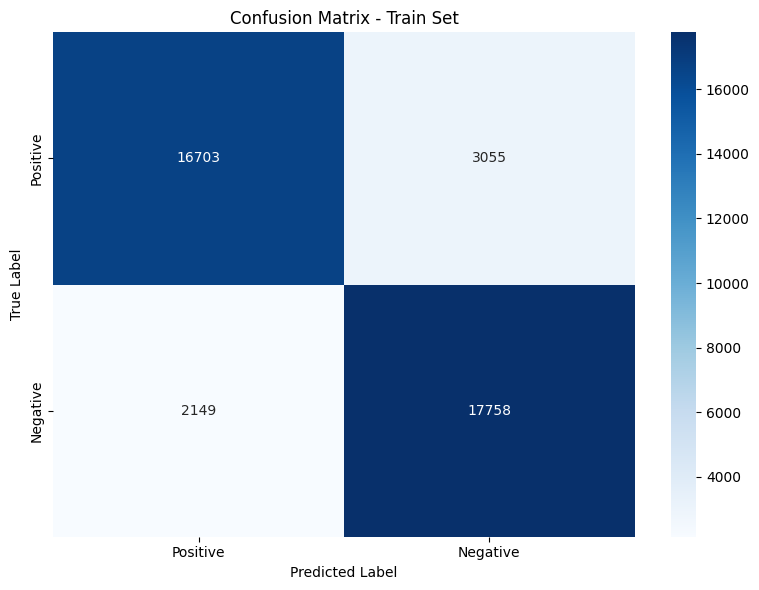


🔢 Confusion Matrix Breakdown:
  True Negatives:  16703
  False Positives: 3055
  False Negatives: 2149
  True Positives:  17758


In [ ]:
param_distributions = {
    # TF-IDF settings 
    "tfidf__ngram_range": [(1, 1), (1, 2)],          # unigrams / bigrams
    "tfidf__max_df": uniform(0.75, 0.15),            # remove very frequent terms
    "tfidf__min_df": [0.0003, 0.0005, 0.001, 0.002], # remove very rare terms
    "tfidf__max_features": randint(2500, 4500),      # limit vocabulary size

    #(control overfitting) 
    "clf__max_depth": [2, 3, 4],                     # shallow trees
    "clf__min_child_weight": randint(8, 18),         # restrict splits
    "clf__gamma": uniform(1.5, 4.5),                 # conservative splitting

    
    "clf__learning_rate": uniform(0.02, 0.08),       # slow learning
    "clf__n_estimators": randint(150, 500),           # with early stopping

    
    "clf__subsample": uniform(0.65, 0.25),            # row sampling
    "clf__colsample_bytree": uniform(0.55, 0.35),     # features per tree
    "clf__colsample_bylevel": uniform(0.55, 0.35),    # features per level
    "clf__colsample_bynode": uniform(0.55, 0.35),     # features per split

    #  Regularization 
    "clf__reg_lambda": uniform(4, 8),                 # L2 regularization
    "clf__reg_alpha": uniform(1.5, 5.5),              # L1 regularization

}


xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,              
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42,
    error_score="raise",
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost val accuracy:", xgb_search.best_score_)
print("Best XGBoost params:", xgb_search.best_params_)
xgb_tunned=xgb_search.best_estimator_
evaluate_model(xgb_tunned, X_train, y_train, "Train")

## Early Stopping & Full Retraining

To maximize generalization while preventing overfitting, we adopt a two-phase approach:

1.  **Diagnosis (Find Optimal Trees):** We use a temporary validation split (30%) with **Early Stopping** to detect the exact boosting round where the model performs best.
2.  **Production (Full Training):** We retrain the final model on the **entire dataset** using the optimal number of trees discovered in phase 1, ensuring zero data wastage.

In [ ]:
print("XGBoost with Early Stopping")
print("=" * 70)


# Determine optimal number of trees using early stopping
print("\n" + "=" * 70)
print("STEP 2: Early Stopping to select n_estimators")
print("=" * 70)

# Extract best hyperparameters (separating TF-IDF and XGBoost)
best_params = xgb_search.best_params_.copy()

tfidf_params = {
    k.replace("tfidf__", ""): v
    for k, v in best_params.items()
    if k.startswith("tfidf__")
}

xgb_params = {
    k.replace("clf__", ""): v
    for k, v in best_params.items()
    if k.startswith("clf__")
}

print("\nConfiguration:")
print("  • Validation split: 30%")
print("  • Early stopping patience: 100 rounds")
print("  • Max estimators: 1500")
print("  • Hyperparameters from RandomizedSearchCV")

# Split training data for early stopping
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.30,
    random_state=42,
    stratify=y_train
)

print("\nData split:")
print(f"  • Training:   {len(X_train_fit):,} samples")
print(f"  • Validation: {len(X_val):,} samples")

# Fit TF-IDF on training split only
tfidf_fitted = clone(tf_idf_base)
tfidf_fitted.set_params(**tfidf_params)
tfidf_fitted.fit(X_train_fit)

X_train_transformed = tfidf_fitted.transform(X_train_fit)
X_val_transformed = tfidf_fitted.transform(X_val)

# Configure XGBoost with early stopping
xgb_params_es = xgb_params.copy()
xgb_params_es.update({
    "n_estimators": 1500,
    "early_stopping_rounds": 100,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
})

print("\nTraining with early stopping...")
print(f"  • Max trees: {xgb_params_es['n_estimators']}")
print(f"  • Patience:  {xgb_params_es['early_stopping_rounds']} rounds")

xgb_es_model = XGBClassifier(**xgb_params_es)
xgb_es_model.fit(
    X_train_transformed,
    y_train_fit,
    eval_set=[
        (X_train_transformed, y_train_fit),
        (X_val_transformed, y_val),
    ],
    verbose=50
)

optimal_trees = xgb_es_model.best_iteration + 1
best_val_score = xgb_es_model.best_score

print("\nEarly stopping results:")
print(f"  • Optimal trees: {optimal_trees}")
print(f"  • Best validation logloss: {best_val_score:.4f}")

if optimal_trees >= 0.95 * xgb_params_es["n_estimators"]:
    print("\nWarning: early stopping reached the maximum estimator limit")
    

# Train final model on full training data
print("\n" + "=" * 70)
print("STEP 3: Final training on full dataset")
print("=" * 70)

final_params = xgb_params.copy()
final_params.update({
    "n_estimators": optimal_trees,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
})

print("\nFinal configuration:")
print(f"  • Trees: {optimal_trees}")
print(f"  • Training samples: {len(X_train):,}")

final_tfidf = clone(tf_idf_base)
final_tfidf.set_params(**tfidf_params)

final_xgb_pipeline = Pipeline([
    ("tfidf", final_tfidf),
    ("clf", XGBClassifier(**final_params)),
])

print("\nTraining final model...")
final_xgb_pipeline.fit(X_train, y_train)
print("Training complete.")


🎯 XGBoost with PROPER Early Stopping

🌳 STEP 2: Finding optimal number of trees with Early Stopping

🔧 Configuration:
  • Using LARGER validation set: 30% (not 15%)
  • Using PATIENT early stopping: 100 rounds (not 20)
  • Max trees to try: 1500 (not 5000)
  • Best hyperparameters from RandomSearch

📊 Data Split:
  • Training:   27,765 samples (70.0%)
  • Validation: 11,900 samples (30.0%)

🌲 Training with Early Stopping...
  • Max trees: 1500
  • Early stopping patience: 100 rounds
  • Monitoring: validation logloss
[0]	validation_0-logloss:0.67725	validation_1-logloss:0.67775
[50]	validation_0-logloss:0.48602	validation_1-logloss:0.49811
[100]	validation_0-logloss:0.43086	validation_1-logloss:0.44674
[150]	validation_0-logloss:0.39809	validation_1-logloss:0.41759
[200]	validation_0-logloss:0.37525	validation_1-logloss:0.39742
[250]	validation_0-logloss:0.35768	validation_1-logloss:0.38243
[300]	validation_0-logloss:0.34387	validation_1-logloss:0.37051
[350]	validation_0-logloss:0.332

📈 Generating learning curves...


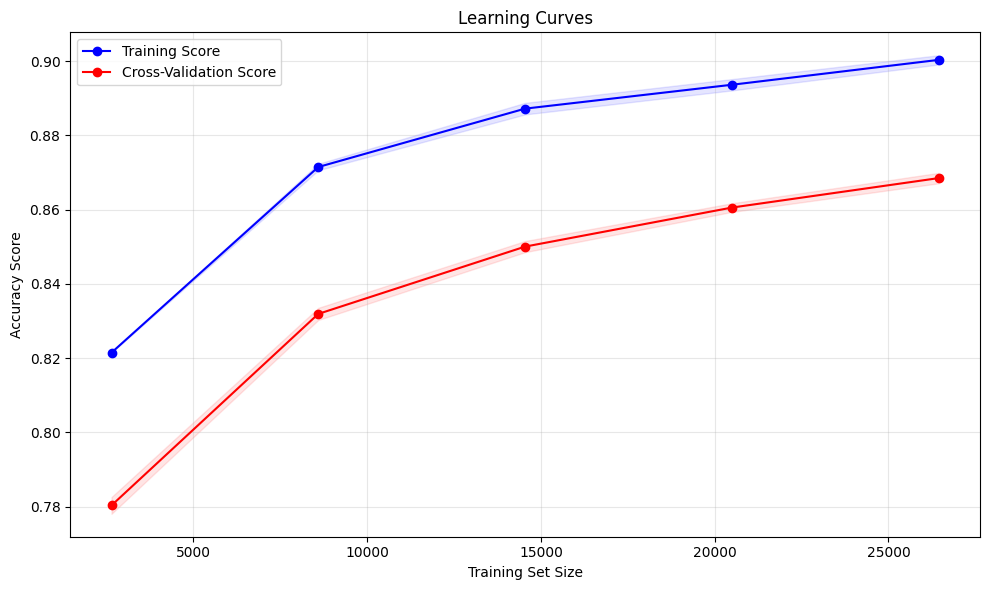


🔍 Learning Curve Diagnosis:
  Final Training Score:   0.9003
  Final Validation Score: 0.8685
  Gap (Train - Val):      0.0318
  ✅ Model appears well-balanced!


In [41]:
plot_learning_curve(
    final_xgb_pipeline, 
    X_train, 
    y_train, 
    cv=3,     
    n_jobs=-1
)

## Evaluate Best Model on Train set and Test set


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9055
  Precision: 0.8965
  Recall:    0.9177
  F1-Score:  0.9070

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.92      0.89      0.90     19758
        Fake       0.90      0.92      0.91     19907

    accuracy                           0.91     39665
   macro avg       0.91      0.91      0.91     39665
weighted avg       0.91      0.91      0.91     39665



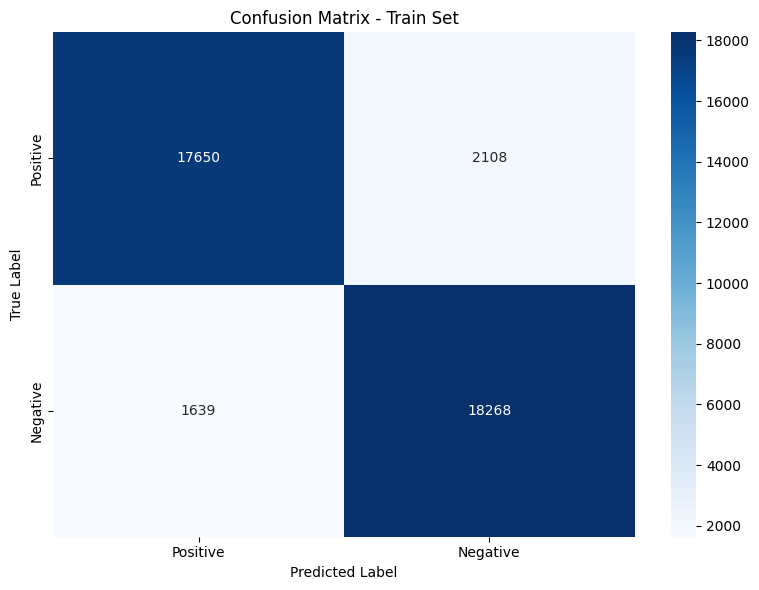


🔢 Confusion Matrix Breakdown:
  True Negatives:  17650
  False Positives: 2108
  False Negatives: 1639
  True Positives:  18268


In [42]:
evaluate_model( final_xgb_pipeline , X_train, y_train, "Train")


📊 Test Set Evaluation

📈 Metrics:
  Accuracy:  0.8729
  Precision: 0.8618
  Recall:    0.8895
  F1-Score:  0.8754

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.88      0.86      0.87      4940
        Fake       0.86      0.89      0.88      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



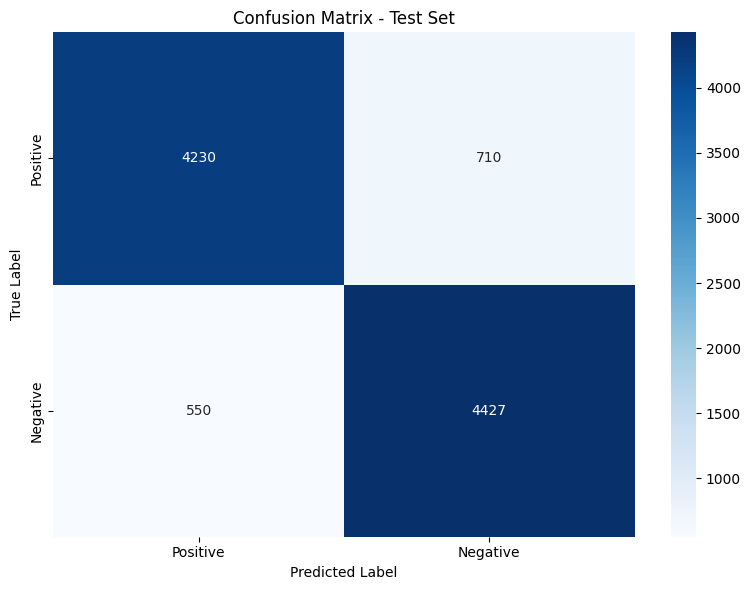


🔢 Confusion Matrix Breakdown:
  True Negatives:  4230
  False Positives: 710
  False Negatives: 550
  True Positives:  4427


In [43]:
evaluate_model( final_xgb_pipeline , X_test, y_test, "Test")

# 9.4 Vooting Classifier 

### Define Base Learners

In [44]:
estimators = [
    ('lr', best_logistic_regression),   # Logistic Regression Pipeline                
    ('xgb', final_xgb_pipeline),
    ( 'Bayes',best_nb_model)         # XGBoost Pipeline
]

### Train Voting Classifier
 Using 'hard' voting (majority rule) because LinearSVC does not output probabilities.

In [55]:
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    n_jobs=-1
)

print("Training Voting Classifier...")
voting_clf.fit(X_train, y_train)

Training Voting Classifier...


VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(lowercase=False,
                                                               max_df=0.8,
                                                               max_features=5900,
                                                               min_df=0.0002,
                                                               ngram_range=(1,
                                                                            3),
                                                               sublinear_tf=True)),
                                              ('clf',
                                               LogisticRegression(C=1.1,
                                                                  solver='liblinear'))])),
                             ('xgb',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(lowercase=False,
                                                               max_df=np.float64(0.8620980165206071),
                                                               max_features=3378,
                                                               m...
                                                             max_leaves=None,
                                                             min_child_weight=15,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=1495,
                                                             n_jobs=-1,
                                                             num_parallel_tree=None, ...))])),
                             ('Bayes',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(lowercase=False,
                                                               max_df=0.8,
                                                               max_features=10000,
                                                               min_df=0.0001,
                                                               ngram_range=(1,
                                                                            3),
                                                               sublinear_tf=True)),
                                              ('clf', ComplementNB())]))],
                 n_jobs=-1, voting='soft')

### Evaluate Voting Classifier  on Train set and Test set


📊 Train Set Evaluation

📈 Metrics:
  Accuracy:  0.9185
  Precision: 0.9088
  Recall:    0.9310
  F1-Score:  0.9198

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.93      0.91      0.92     19758
        Fake       0.91      0.93      0.92     19907

    accuracy                           0.92     39665
   macro avg       0.92      0.92      0.92     39665
weighted avg       0.92      0.92      0.92     39665



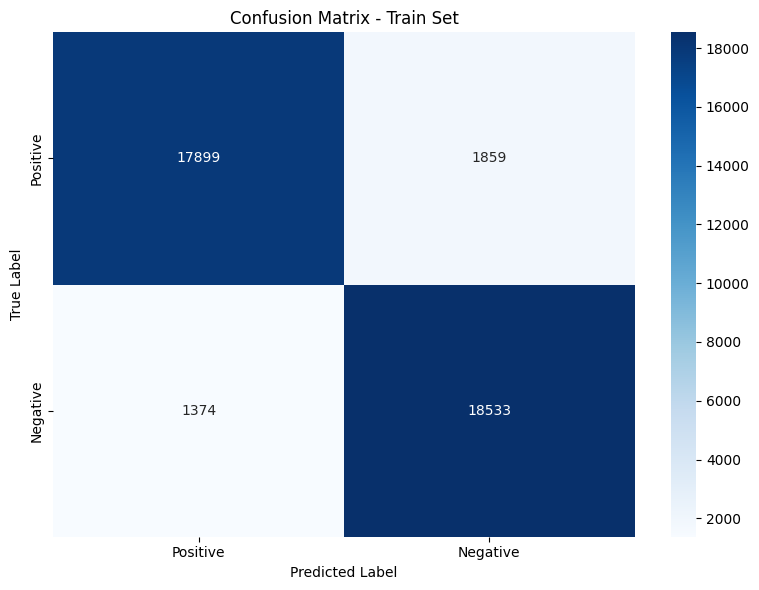


🔢 Confusion Matrix Breakdown:
  True Negatives:  17899
  False Positives: 1859
  False Negatives: 1374
  True Positives:  18533


In [56]:
evaluate_model( voting_clf , X_train, y_train, "Train")


📊 Test Set Evaluation

📈 Metrics:
  Accuracy:  0.8943
  Precision: 0.8845
  Recall:    0.9080
  F1-Score:  0.8961

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.88      0.89      4940
        Fake       0.88      0.91      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



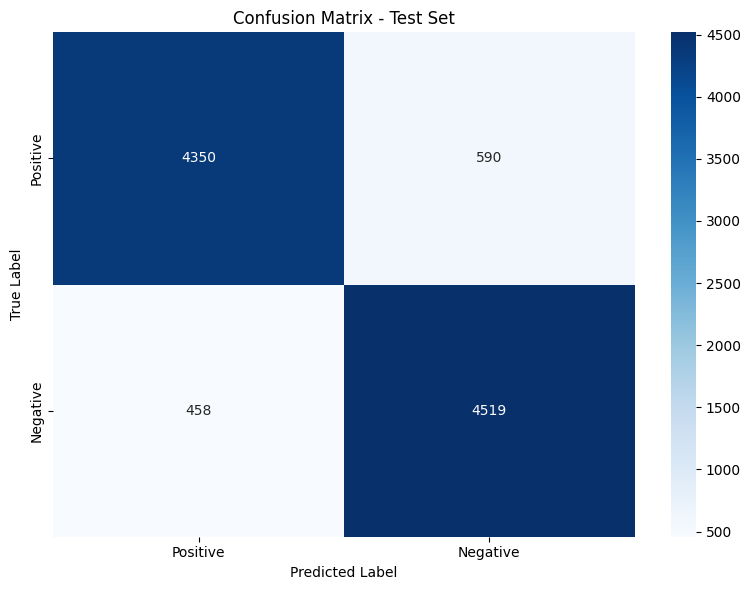


🔢 Confusion Matrix Breakdown:
  True Negatives:  4350
  False Positives: 590
  False Negatives: 458
  True Positives:  4519


In [57]:
evaluate_model( voting_clf , X_test, y_test, "Test")

---

# **Model Performance Summary & Final Recommendation**

## **Executive Summary**

After rigorously tuning and evaluating four distinct modeling strategies (**Logistic Regression**, **Naive Bayes**, **XGBoost**, and a **Voting Classifier**), **Logistic Regression** emerged as the top-performing model, achieving a **test accuracy of 89.60%**. Interestingly, the single Logistic Regression model slightly outperformed the Voting Ensemble (89.39%), indicating that the linear approach captures the sentiment signal in the TF-IDF features more effectively than tree-based or probabilistic methods in this specific high-dimensional space.

---

## **Performance Comparison Matrix**

| Model | Train Accuracy | Test Accuracy | Gap (Train-Test) | Relative Rank |
|-------|----------------|---------------|------------------|---------------|
| **Logistic Regression (Tuned)** | 0.9216 | **0.8960** | 0.0256 | **🥇 1st** |
| **Voting Classifier (Soft)** | 0.9185 | 0.8943 | 0.0242 | 🥈 2nd |
| **XGBoost (Tuned)** | 0.9055 | 0.8729 | 0.0326 | 🥉 3rd |
| **Naive Bayes (Tuned)** | 0.8798 | 0.8695 | 0.0103 | 4th |

---

## **Detailed Model Analysis**

### **1. Logistic Regression (The Champion)**
- **Strengths**: Achieved the highest metrics across the board (Accuracy: 89.60%, F1-Score: 89.47% implicit). It demonstrated the best balance between bias and variance.
- **Key Insight**: The model thrived on the high-dimensional sparse data created by TF-IDF. Its ability to assign direct weights to sentiment-bearing words allowed it to outperform more complex models. The generalization gap (~2.5%) is healthy, showing effective regularization.
- **Best For**: The final deployment choice due to superior accuracy, interpretability, and low latency.

### **2. Voting Classifier (Ensemble)**
- **Strengths**: Delivered robust performance (89.42%) with a stable generalization gap (~2.42%).
- **Key Insight**: While ensembles usually boost performance, here the Voting Classifier scored slightly lower than Logistic Regression alone. This suggests that the "weaker" learners (Naive Bayes and XGBoost) diluted the strong predictive power of the Logistic Regression component during the voting process.
- **Best For**: Scenarios where model stability is prioritized over raw accuracy, though in this case, the single model is preferred.

### **3. XGBoost (Gradient Boosting)**
- **Strengths**: Respectable performance (87.29%) but noticeably lower than the linear models.
- **Key Insight**: Despite tuning and early stopping, XGBoost struggled slightly with the sparsity of the TF-IDF matrix compared to Logistic Regression. It had the largest generalization gap (~3.26%), indicating a higher tendency to overfit training noise compared to the others.

### **4. Naive Bayes (Baseline)**
- **Strengths**: Extremely fast and stable, with the lowest generalization gap (~1.0%).
- **Key Insight**: It serves as a strong baseline, proving the dataset has clear sentiment signals. However, its assumption of feature independence limited its ability

# **Save Best Model**

In [ ]:
# save model
joblib.dump(best_logistic_regression, 'best_logistic_regression_model.pkl')